# Generative Adversarial Networks

**Generative adversarial networks** offer a radically different answer to the generative modeling problem. Instead of writing a tractable density and optimizing its log-likelihood or a variational lower bound, GANs learn through competition. A **generator network** $G_\theta$ transforms a simple latent variable $\boldsymbol{z} \sim p(\boldsymbol{z})$ into a synthetic image $G_\theta(\boldsymbol{z})$. A **discriminator network** $D_\psi$ receives either a real image or a generated one and outputs a score interpreted as evidence that the input came from the data distribution. Training is then expressed as a **two-player game**: the discriminator tries to separate real samples from generated samples, while the generator tries to make generated samples indistinguishable from real ones.

This formulation is historically important because it demonstrated that one can learn a high-quality **implicit generative model** without evaluating a density explicitly {cite}`goodfellow2014generative`. The induced model distribution is the **pushforward** of the latent prior through the generator:

$$
\boldsymbol{z} \sim p(\boldsymbol{z}), \qquad
\boldsymbol{x} = G_\theta(\boldsymbol{z}), \qquad
\boldsymbol{x} \sim p_\theta.
$$

Sampling is easy because it only requires drawing $\boldsymbol{z}$ and running a neural network forward. Density evaluation is generally intractable because the generator may be non-invertible, lower-dimensional, or too complicated to give an explicit formula for $p_\theta(\boldsymbol{x})$. This is the first major contrast with VAEs. A VAE gives a probabilistic model with an approximate likelihood objective, but samples can be blurry when the decoder and latent regularization compromise too strongly. A GAN gives no tractable likelihood, but it can produce sharp samples because the discriminator learns a data-**adaptive notion of realism**.

The motivation can be stated simply. Instead of telling the generator exactly which target image it should reproduce, we train a critic that asks whether a generated image belongs to the same visual population as the real images. This is much closer to how image quality is often judged: not by pixelwise similarity to one prescribed target, but by whether the sample looks like it could have come from the dataset. The price is that the learning problem is no longer a single minimization problem. It is a game, and games can oscillate, become unbalanced, or converge to poor partial solutions.

```{figure} ../assets/images/GAN_diagram.png
:width: 66%
:align: center

A representation of the GAN 2-player game.
```

Adversarial learning should be read as a direct response to the limitations of likelihood-based image generation. In the VAE, the decoder is trained through an explicit likelihood term, and the latent representation is shaped by the **KL term** in the ELBO. This gives a clear probabilistic objective, but pixelwise likelihoods and latent regularization can favor smooth reconstructions. A GAN removes the explicit likelihood and replaces it with a learned comparison between real and generated samples.

The contrast is structural. VAEs keep the density model explicit and pay the price of approximate inference through the variational posterior. GANs give up tractable density evaluation and learn through a discriminator. Both are deep generative models, but they make different compromises between likelihood, sample sharpness, latent interpretability, and optimization stability.

The compactness of the GAN objective is deceptive. The equations are short, but the optimization problem is delicate because the loss seen by each network depends on the current state of the other network. A generator can improve only through the discriminator's feedback, while the discriminator's feedback is useful only if it is neither too weak nor too dominant. GANs therefore make **optimization dynamics** part of the modeling story.

The contrast with likelihood-based models is especially important. In a VAE there is a probability model, a lower bound, and an explicit approximate posterior. In a GAN there is no tractable density assigned to an image. Instead, generated samples are judged by whether a learned critic can distinguish them from real samples. The objective is relational rather than absolute. The generator is evaluated by the current state of its adversary, which makes the method powerful but also sensitive to balance, architecture, and training schedule.

```{admonition} GAN versus VAE
:class: note

A VAE learns through an explicit likelihood bound and an approximate posterior. A GAN learns through samples and a discriminator. The first gives tractable probabilistic structure; the second gives an **adaptive notion of realism**.
```

## The Minimax Objective

Let $p_{gt}$ be the data distribution on images and let $p_\theta$ be the distribution induced by $G_\theta(\boldsymbol{z})$ when $\boldsymbol{z} \sim p(\boldsymbol{z})$. The original GAN objective is

:::{math}
\min_\theta \max_\psi V(D_\psi, G_\theta)
=
\mathbb{E}_{\boldsymbol{x} \sim p_{gt}}[\log D_\psi(\boldsymbol{x})]
+
\mathbb{E}_{\boldsymbol{z} \sim p(\boldsymbol{z})}
[\log(1 - D_\psi(G_\theta(\boldsymbol{z})))].
:::

It is useful to interpret the two terms as a **binary classification problem**. Real images receive label one, generated images receive label zero, and the discriminator is trained with the log-likelihood of the correct labels. For a fixed generator, the discriminator is just a classifier between two distributions: $p_{gt}$ and $p_\theta$. For a fixed discriminator, the generator changes $p_\theta$ by moving the images produced from latent samples.

The adversarial aspect is not a superficial metaphor. The discriminator wants $D_\psi(\boldsymbol{x})$ to be large on real samples and small on generated samples. The generator wants the second term to become large by making $D_\psi(G_\theta(\boldsymbol{z}))$ large. Therefore, the same generated sample creates opposite incentives for the two networks. This is why GAN training cannot be understood exactly like supervised training with a fixed loss function. The loss landscape seen by one player changes as soon as the other player updates.

From a theoretical perspective, the minimax formulation is valuable because it connects adversarial training to a divergence between probability distributions. With an **optimal discriminator**, the game minimizes a quantity related to the **Jensen-Shannon divergence** between $p_{gt}$ and $p_\theta$. From a motivational perspective, it says something more concrete: if the discriminator cannot tell real and generated samples apart, then the generator has learned to reproduce the data distribution at the level of the discriminator's tests. The entire difficulty is hidden in the phrase "at the level of the discriminator's tests." A weak discriminator gives weak tests. An overpowered discriminator can give unhelpful gradients. A balanced discriminator gives a useful learning signal.

```{figure} ../assets/images/GAN_training.png
:width: 66%
:align: center

A schematic representation of the typical training dynamics.
```

The objective also deserves interpretation as a classification problem. If real and generated samples are mixed with equal prior probability, then the discriminator is solving a binary decision task whose positive class is "came from the data" and whose negative class is "came from the generator." The log terms in the GAN objective are therefore exactly the log-likelihood terms of a probabilistic classifier. This observation is not merely cosmetic. It explains why the discriminator learns quickly at the beginning of training: early fake samples are often easy to reject, so the classification task is simple. The difficulty begins when one asks whether the gradients produced by that classifier remain useful for improving the generator.

```{figure} ../assets/images/GAN_before-after-training.png
:width: 66%
:align: center

When the generator quality is bad, the discriminator trivially recognize true vs fake images. When the generator becomes good, the task of the discrimiator becomes harder.
```

At a deeper level, GANs replace direct probabilistic modeling of $p_{gt}$ by a test of indistinguishability. The generator succeeds when generated samples become hard to separate from real ones by a critic drawn from a rich function class. This connects GANs to a broader family of ideas in statistics and machine learning where distributions are compared through witnesses, critics, or integral probability metrics rather than through tractable density formulas.

```{prf:theorem} Optimal discriminator for a fixed generator
:label: thm-gan-optimal-discriminator

Fix a generator and its induced distribution $p_\theta$. For every point $\boldsymbol{x}$ such that $p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x}) > 0$, the discriminator that maximizes the GAN value function is
:::{math}
D^\star(\boldsymbol{x})
=
\frac{p_{gt}(\boldsymbol{x})}{p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x})}.
:::
```

```{prf:proof}
For a fixed generator, the objective can be written pointwise as
:::{math}
V(D, G_\theta)
=
\int
p_{gt}(\boldsymbol{x}) \log D(\boldsymbol{x})
+
p_\theta(\boldsymbol{x}) \log(1 - D(\boldsymbol{x}))
\, d\boldsymbol{x}.
:::
Since the integrand decouples in $\boldsymbol{x}$, we maximize
:::{math}
f(d) = a \log d + b \log(1-d)
:::
for $a = p_{gt}(\boldsymbol{x})$ and $b = p_\theta(\boldsymbol{x})$. Differentiating gives
:::{math}
f'(d) = \frac{a}{d} - \frac{b}{1-d}.
:::
Setting this derivative equal to zero yields
:::{math}
a(1-d) = bd,
\qquad
d = \frac{a}{a+b}.
:::
Because
:::{math}
f''(d) = -\frac{a}{d^2} - \frac{b}{(1-d)^2} < 0,
:::
this critical point is the unique maximizer. Substituting back $a = p_{gt}(\boldsymbol{x})$ and $b = p_\theta(\boldsymbol{x})$ gives the claimed formula.
```

The formula for $D^\star$ is revealing. An **optimal discriminator** does not memorize examples individually. It compares the relative mass that the real and generated distributions assign to each region of image space. Regions where the generator oversamples relative to the data are penalized, and regions where the data dominate are rewarded. This is the first hint that adversarial learning is implicitly minimizing a divergence between distributions rather than matching samples one by one.

The discriminator is often described informally as detecting realism, but the formula is more precise. It says that the ideal discriminator estimates a **density ratio**. In regions where the generator places too much mass relative to the data, the discriminator moves downward. In regions where the data dominate, it moves upward. The generator therefore receives a signal about where its distribution is misallocated, even though no explicit density is evaluated.

```{prf:theorem} The GAN game and **Jensen-Shannon divergence**
:label: thm-gan-jsd

Let $D^\star$ be the **optimal discriminator** for a fixed generator. Then
:::{math}
V(D^\star, G_\theta)
=
-\log 4 + 2 \operatorname{JSD}(p_{gt} \| p_\theta),
:::
where $\operatorname{JSD}$ denotes the **Jensen-Shannon divergence**. Consequently, if the discriminator is optimal at each step, minimizing the GAN objective with respect to the generator amounts to minimizing the **Jensen-Shannon divergence** between the data and model distributions.
```

```{prf:proof}
Substitute the **optimal discriminator** into the value function:
:::{math}
V(D^\star, G_\theta)
=
\int p_{gt}(\boldsymbol{x})
\log \frac{p_{gt}(\boldsymbol{x})}{p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x})}
\, d\boldsymbol{x}
+
\int p_\theta(\boldsymbol{x})
\log \frac{p_\theta(\boldsymbol{x})}{p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x})}
\, d\boldsymbol{x}.
:::
Let
:::{math}
m(\boldsymbol{x}) = \frac{1}{2}(p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x})).
:::
Then
:::{math}
\log \frac{p_{gt}(\boldsymbol{x})}{p_{gt}(\boldsymbol{x}) + p_\theta(\boldsymbol{x})}
=
\log \frac{p_{gt}(\boldsymbol{x})}{2m(\boldsymbol{x})}
=
\log \frac{p_{gt}(\boldsymbol{x})}{m(\boldsymbol{x})} - \log 2,
:::
and similarly for the second term. Therefore
:::{math}
V(D^\star, G_\theta)
=
\operatorname{KL}(p_{gt} \| m)
+
\operatorname{KL}(p_\theta \| m)
-
2 \log 2.
:::
By definition,
:::{math}
\operatorname{JSD}(p_{gt} \| p_\theta)
=
\frac{1}{2}\operatorname{KL}(p_{gt} \| m)
+
\frac{1}{2}\operatorname{KL}(p_\theta \| m).
:::
Hence
:::{math}
V(D^\star, G_\theta)
=
2 \operatorname{JSD}(p_{gt} \| p_\theta) - \log 4.
:::
This proves the claim.
```

The theorem is elegant, but it must be interpreted carefully. In practice the discriminator is never optimized exactly, the generator and discriminator are finite neural networks, and stochastic gradient descent only approximates the game dynamics. The Jensen-Shannon interpretation is therefore a guiding idealization rather than a literal description of every training step. Still, it explains why GANs are not arbitrary heuristics. They instantiate a principled distribution-matching game.

This is also the right place to explain why the theory can look stronger than the practice. The **Jensen-Shannon divergence** is perfectly meaningful when both distributions are fixed objects and the discriminator is optimized over all measurable functions. But actual GAN training lives in a restricted and moving landscape: the discriminator is a finite neural network, the generator changes after every update, minibatches add stochastic noise, and the two players may learn on different time scales. As a consequence, one should think of the theorem as describing the ideal geometry that motivates the method, not as proving that every practical run of SGD is faithfully minimizing **Jensen-Shannon divergence** step by step.

A further subtlety becomes important in high-dimensional image generation. When the supports of $p_{gt}$ and $p_\theta$ are far apart or lie on thin lower-dimensional sets, the **Jensen-Shannon divergence** can become locally uninformative. Intuitively, if the discriminator can separate real and fake samples almost perfectly, then its output may saturate near zero or one on most of the relevant regions, and the generator may receive poor directional guidance. This is one of the reasons the original GAN formulation produced stunning visual results but also inspired a large stabilization literature. The issue is not that the theory is wrong. The issue is that the geometry induced by **Jensen-Shannon divergence** may be awkward for gradient-based optimization when distributions overlap weakly.

## Why the Original Generator Loss Can Saturate

The word *saturate* deserves a more explicit explanation than it often receives in brief presentations. Suppose the generator is poor and the discriminator is already very confident, so that $D_\psi(G_\theta(\boldsymbol{z})) \approx 0$ for most latent samples. In the minimax loss, the quantity $\log(1 - D_\psi(G_\theta(\boldsymbol{z})))$ is then close to $\log 1 = 0$, and the derivative that reaches the generator may become very small after passing through the discriminator's nonlinearities. The problem is not simply that the loss value is large or small. The problem is that the gradient field can become weak exactly when the generator most needs useful corrective information.

This can be seen directly at the level of the discriminator logit. Let

:::{math}
a_\psi(\boldsymbol{x}) \in \mathbb{R},
\qquad
D_\psi(\boldsymbol{x}) = \sigma(a_\psi(\boldsymbol{x})).
:::

For one generated sample $\boldsymbol{x}_\theta = G_\theta(\boldsymbol{z})$, the **saturating minimax generator loss** is

:::{math}
\ell_{\mathrm{sat}}(a)
=
\log(1-\sigma(a)).
:::

Using $\sigma'(a)=\sigma(a)(1-\sigma(a))$,

:::{math}
\frac{d\ell_{\mathrm{sat}}}{da}
=
\frac{-\sigma'(a)}{1-\sigma(a)}
=
-\sigma(a).
:::

When the discriminator confidently rejects the fake sample, $a \ll 0$ and $\sigma(a)\approx 0$. Therefore

:::{math}
\frac{d\ell_{\mathrm{sat}}}{da}
\approx 0.
:::

The gradient passed to the generator is proportional to this factor:

:::{math}
\nabla_\theta \ell_{\mathrm{sat}}
=
-\sigma(a_\psi(\boldsymbol{x}_\theta))
\nabla_{\boldsymbol{x}}a_\psi(\boldsymbol{x}_\theta)
\nabla_\theta G_\theta(\boldsymbol{z}).
:::

The **non-saturating loss** is instead

:::{math}
\ell_{\mathrm{NS}}(a)
=
-\log \sigma(a).
:::

Its derivative is

:::{math}
\frac{d\ell_{\mathrm{NS}}}{da}
=
-
\frac{\sigma'(a)}{\sigma(a)}
=
-(1-\sigma(a))
=
\sigma(a)-1.
:::

When $a \ll 0$, $\sigma(a)\approx 0$, and therefore

:::{math}
\frac{d\ell_{\mathrm{NS}}}{da}
\approx
-1.
:::

Thus the **non-saturating loss** does not vanish at the discriminator-logit level precisely in the regime where the minimax generator loss saturates. The complete generator gradient is still shaped by the discriminator Jacobian and the generator Jacobian, but the scalar loss factor no longer collapses to zero just because the discriminator is confidently rejecting fake samples.

```{admonition} Saturating versus non-saturating
:class: warning

When $D_\psi(G_\theta(\boldsymbol{z}))\approx 0$, the minimax generator loss has logit derivative close to $0$, while the **non-saturating loss** has logit derivative close to $-1$. The two objectives have the same target equilibrium but very different early-training gradients.
```

The distinction between the minimax and non-saturating generator losses illustrates a broader principle. Two objectives can share the same desired equilibrium while producing very different gradients on the way there. In adversarial learning, the optimization surrogate is part of the method. Later objectives such as score matching and flow matching follow a related philosophy: difficult distributional learning problems are rewritten into forms that provide more stable learning signals.

## Mode Collapse

One of the central pathologies of GAN training is **mode collapse**. The data distribution may have many distinct modes corresponding to different object classes, poses, textures, or styles. A generator trained adversarially can sometimes discover that producing only a small subset of visually convincing outputs is enough to fool the current discriminator. Sample quality may look high locally, while sample diversity is poor globally.

This is a **distributional failure**, not merely a visual annoyance. If the true data distribution contains sandals, shirts, trousers, coats, bags, and boots, a generator that produces only boots has not learned Fashion MNIST, even if each generated boot looks sharp. The discriminator may eventually notice the missing categories, but the generator can react by moving toward another narrow subset instead of spreading probability mass across the full distribution. The resulting trajectory can oscillate between partial solutions.

The theoretical reason is that the generator is trained through samples, not through an explicit enumeration of all missing probability mass. If the current discriminator gives a strong reward for a limited set of outputs, gradient descent can increase the probability of those outputs even when other modes are uncovered. The motivational version is simple: the generator can learn shortcuts. It may learn what currently fools the critic rather than what fully represents the dataset.

**Mode collapse** is one reason GAN evaluation is subtle. A small grid of generated images can be misleading because it may show only successful samples. **FID** and **KID** are useful because they compare distributions in a feature space, but even these metrics are imperfect and should be read together with class coverage, interpolation behavior, and visual inspection. The key point is that **sharpness** and **diversity** are different properties. GANs often improve sharpness before they solve coverage.

```{figure} ../assets/images/GAN_model_collapse_local_minima.png
:width: 66%
:align: center

Mode collapse corresponds to local minima where both the generator and the discriminator won't improve.
```

A helpful intuition is to imagine a dataset containing several well-separated semantic groups, such as shoes, bags, and coats. If the current discriminator is not yet sensitive to the absence of some groups, the generator may learn that producing only one or two convincing categories yields a strong short-term reward. Once that happens, the discriminator eventually adapts, but the generator may then jump toward a different narrow subset rather than spreading its mass more evenly across the full data distribution. The resulting training trajectory can oscillate between partial solutions instead of converging to broad coverage.

This interpretation is useful because it prevents a common misunderstanding. **Mode collapse** is not simply "the generator repeats the same picture" in a trivial memorization sense. It is a **distributional failure** in which the generator allocates probability mass too narrowly relative to the diversity of the data. The samples may still look sharp and varied at first glance, especially to a casual observer. The failure becomes visible only when one asks whether the whole dataset is represented fairly. This is one reason evaluation in GANs is subtle: visual inspection alone is informative but not sufficient.

## From Vanilla GANs to Stabilized Variants

The vanilla GAN exposes three practical questions. What discrepancy gives useful gradients when $p_{gt}$ and $p_\theta$ barely overlap? How should the discriminator or critic be constrained so that it does not become too sharp? How can generation be controlled by labels or other side information?

These questions lead to WGAN-GP, **spectral normalization**, and **conditional GAN**s. The detailed derivations and implementations are developed in {doc}`variants-and-modern-practice`, where the variants are compared under a shared evaluation pipeline.

GANs occupy a different position from VAEs in the generative-modeling landscape. VAEs emphasize explicit probabilistic structure, variational inference, and a tractable lower bound. GANs sacrifice explicit likelihood evaluation and instead learn through an adaptive critic. This can produce sharper samples, but it also introduces game dynamics, **mode collapse**, and sensitivity to critic control. Diffusion models later return to explicit probabilistic reasoning through denoising trajectories rather than adversarial games.

The original GAN formulation is due to {cite}`goodfellow2014generative`. Stabilized and controlled variants include WGAN-GP {cite}`arjovsky2017wasserstein,gulrajani2017improved`, **spectral normalization** {cite}`miyato2018spectral`, **conditional GAN**s {cite}`mirza2014conditional`, and CycleGAN {cite}`zhu2017unpaired`.

## Vanilla GAN Implementation

The minimal GAN code exposes the central adversarial mechanics: data scaling, generator upsampling, discriminator downsampling, non-saturating generator loss, and alternating optimization.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers = 0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# DCGAN-style settings are still teachable but produce much better samples.
latent_dim = 128
base_channels = 64
batch_size = 128
lr = 2e-4
epochs = 60

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: 2.0 * x - 1.0),
])

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


The hyperparameters are chosen to give the adversarial game enough time to develop recognizable image structure. `FashionMNIST` is small, but GANs usually need a longer optimization horizon than one might guess from the compactness of the equations. Moving losses are easy to obtain; coherent samples require a more stable interaction between generator and discriminator.

The vanilla GAN below is trained for `60` epochs with a DCGAN-style architecture and standard Adam settings. This is still a small run, but it is long enough for the model to move beyond obviously immature generations.

## Generator and Discriminator Architectures

```{figure} ../assets/images/GAN_architecture.png
:width: 76%
:align: center

A standard GAN architecture: a generator maps noise to images, while a discriminator learns to distinguish real samples from generated ones.
```

The generator starts from a latent vector and progressively expands it into spatial feature maps. The discriminator performs the opposite movement, reducing an image to a realism score. This asymmetry is not accidental. One network is learning how to *synthesize* spatial structure, the other how to *detect* whether that structure looks data-like.

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=128, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, base_channels * 4 * 7 * 7),
            nn.BatchNorm1d(base_channels * 4 * 7 * 7),
            nn.ReLU(True),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(True),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, base_channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(base_channels * 2 * 7 * 7, 1),
        )

    def forward(self, x):
        return self.net(x)


G = Generator(latent_dim=latent_dim, base_channels=base_channels).to(device)
D = Discriminator(base_channels=base_channels).to(device)

g_optimizer = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

Compared with the VAE, the architecture already reflects a different philosophy. There is no explicit encoder and no tractable likelihood. The discriminator is not a probabilistic posterior approximation. It is an adaptive critic whose only job is to shape the generator's gradients. That difference is why GAN code can be shorter than VAE code while still being harder to tune.

```{admonition} Alternating optimization
:class: note

The discriminator update uses detached fake samples. The generator update uses the current discriminator as a learned loss function. This separation is essential: both networks should not be updated by the same backward pass.
```

In [4]:
def discriminator_loss(real_logits, fake_logits):
    # Mild one-sided label smoothing usually stabilizes the discriminator.
    real_targets = torch.full_like(real_logits, 0.9)
    fake_targets = torch.zeros_like(fake_logits)

    real_loss = F.binary_cross_entropy_with_logits(real_logits, real_targets)
    fake_loss = F.binary_cross_entropy_with_logits(fake_logits, fake_targets)
    return real_loss + fake_loss


def generator_loss(fake_logits):
    # Non-saturating loss: the generator wants fake samples judged as real.
    real_targets = torch.ones_like(fake_logits)
    return F.binary_cross_entropy_with_logits(fake_logits, real_targets)

This pair of functions maps directly onto the theory. The discriminator loss combines one term for real images and one term for fake images. The generator loss is the **non-saturating alternative**, so fake logits are compared against a target of one. In words, the generator is trained as if its own samples should be classified as real. The generator never sees real images directly in its loss. It only sees how the discriminator currently reacts to its outputs.

The literal minimax generator objective would require only a small code change, but the non-saturating objective gives stronger gradients when the discriminator confidently rejects generated samples. The implementation therefore follows the practical objective derived above rather than the saturating generator loss.

## Alternating Optimization in Practice

The training loop is where GANs stop looking like ordinary supervised models. We first update the discriminator on real data and on **detached** fake samples. Then we update the generator against the current discriminator. The `detach()` call is not cosmetic: it prevents the generator from receiving gradients during the discriminator step.

In [5]:
history = {"d_loss": [], "g_loss": []}


fixed_z = torch.randn(16, latent_dim, device=device)

for epoch in tqdm(range(epochs), desc="GAN epochs"):
    d_running = 0.0
    g_running = 0.0

    for real_images, _ in tqdm(train_loader, desc="train", leave=False):
        real_images = real_images.to(device)
        batch_n = real_images.size(0)

        # First update the discriminator on real and detached fake samples.
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = G(z)

        d_optimizer.zero_grad()
        real_logits = D(real_images)
        fake_logits = D(fake_images.detach())
        d_loss = discriminator_loss(real_logits, fake_logits)
        d_loss.backward()
        d_optimizer.step()

        # Then update the generator against the current discriminator.
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = G(z)

        g_optimizer.zero_grad()
        fake_logits = D(fake_images)
        g_loss = generator_loss(fake_logits)
        g_loss.backward()
        g_optimizer.step()

        d_running += d_loss.item()
        g_running += g_loss.item()

    d_epoch = d_running / len(train_loader)
    g_epoch = g_running / len(train_loader)
    history["d_loss"].append(d_epoch)
    history["g_loss"].append(g_epoch)

    print(
        f"Epoch {epoch + 1:02d} | "
        f"D loss: {d_epoch:.4f} | "
        f"G loss: {g_epoch:.4f}"
    )

GAN epochs:   0%|          | 0/60 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 01 | D loss: 0.8690 | G loss: 1.7898


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 02 | D loss: 0.8822 | G loss: 1.6706


...

Epoch 58 | D loss: 1.2655 | G loss: 1.0364


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 59 | D loss: 1.2654 | G loss: 1.0409


train:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 60 | D loss: 1.2630 | G loss: 1.0405


This alternating structure is the main reason GAN training feels dynamic rather than static. The loss landscape is being reshaped after every step because one player changes the objective seen by the other. This is why interpreting GAN losses requires more care than interpreting VAE losses. A rising generator loss is not automatically bad, and a tiny discriminator loss is not automatically good.

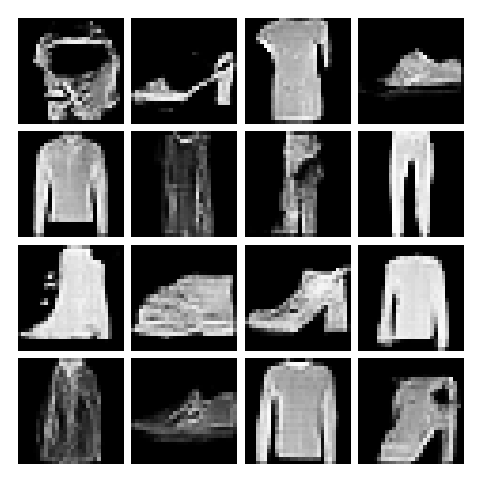

In [6]:
@torch.no_grad()
def show_gan_samples(generator, device, n=16):
    generator.eval()
    z = fixed_z[:n] if n <= fixed_z.size(0) else torch.randn(n, latent_dim, device=device)
    samples = generator(z).view(-1, 1, 28, 28)
    # Undo tanh scaling for display.
    samples = 0.5 * (samples + 1.0)
    image = utils.make_grid(samples.cpu(), nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()
    generator.train()


show_gan_samples(G, device)

A successful run should move from amorphous noise toward recognizable clothing silhouettes, often with sharper edges than a comparably small VAE produces. Imperfections remain expected: repeated shapes, missing classes, unstable textures, and sensitivity to random initialization are common symptoms of adversarial optimization.

Several failure modes have recognizable signatures. If all samples look nearly identical, **mode collapse** or an overpowered discriminator is likely. If both losses oscillate wildly and samples never improve, learning rates may be too large or the network balance may be poor. If samples remain pure noise while the discriminator loss drops immediately, the discriminator may be learning too fast relative to the generator. GAN losses must be interpreted dynamically, together with visual samples and distribution-level metrics.

## Distribution-Level Evaluation

Because GANs can look sharp while still collapsing onto too few modes, quantitative distribution-level metrics are particularly valuable here. **FID** and **KID** do not solve evaluation completely, but they provide a useful complement to image grids and make the discussion of **mode collapse** more concrete.

In [7]:
def prepare_for_inception_metrics(images):
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_gan_fid_and_kid(generator, real_loader, device, num_fake=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    seen_real = 0
    real_target = num_fake
    for real_images, _ in tqdm(real_loader, desc="GAN real metrics", leave=False):
        remaining = real_target - seen_real
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = prepare_for_inception_metrics(0.5 * (real_images + 1.0))
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    generated = 0
    pbar = tqdm(total=num_fake, desc="GAN fake metrics", leave=False)
    while generated < num_fake:
        batch_n = min(metric_batch_size, num_fake - generated)
        z = torch.randn(batch_n, latent_dim, device=device)
        fake_images = generator(z).view(-1, 1, 28, 28)
        # Undo tanh scaling so the metric sees images in [0, 1].
        fake_images = 0.5 * (fake_images + 1.0)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


metric_scores = compute_gan_fid_and_kid(G, train_loader, device)
print(metric_scores)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


GAN real metrics:   0%|          | 0/469 [00:00<?, ?it/s]

GAN fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 35.17267987394109, 'kid_mean': 0.008487868122756481, 'kid_std': 0.002478910144418478}


This metric block is especially useful for discussing **mode collapse**. A GAN may improve visually while still obtaining disappointing FID or KID if it allocates mass too narrowly over the dataset. That makes these scores a nice complement to image grids: the image grid shows local sharpness, while **FID** and **KID** say something more about global coverage.

The adversarial game is meaningful because the **optimal discriminator** connects the objective to a divergence between distributions. Its practical difficulty comes from the same source: the discriminator is learned, so the generator's training signal changes throughout optimization. Saturation, **mode collapse**, Lipschitz control, and **non-saturating loss**es are all consequences of this game structure.